#### test contry analysis

In [1]:
import sys
from pathlib import Path

project_root = Path("..").resolve()
sys.path.append(str(project_root))

import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
from src.country_analysis import summarize_by_country, shipments_count_by_country, top_countries_by_value, shipment_mode_by_country, run_country_analysis, plot_top_countries_by_revenue

In [3]:
from src.cleaning import DATE_COLUMNS, clean
from src.vendor_analysis import run_vendor_analysis
from src.country_analysis import summarize_by_country, shipments_count_by_country, top_countries_by_value, shipment_mode_by_country, run_country_analysis, plot_top_countries_by_revenue
from src.product_analysis import run_product_analysis
from src.shipment_summary import run_shipment_summary

In [4]:
INPUT_PATH = "../data/supply_delivery_history.csv"
OUTPUT_PATH = "../data/supply_delivery_history_clean.csv"

In [5]:
df = pd.read_csv(INPUT_PATH, dtype=str)
print(f"Loaded {len(df):,} rows x {len(df.columns)} columns")

df_clean = clean(df)

# --- Summary report ---
print("\n--- Cleaning summary ---")

print("\nDate columns (NaT count):")
for col in DATE_COLUMNS:
    print(f"  {col}: {df_clean[col].isna().sum()} unparseable/missing")

print("\nNumeric columns (NaN count):")
for col in ("Line Item Quantity", "Line Item Value", "Pack Price", "Unit Price",
            "Weight (Kilograms)", "Freight Cost (USD)", "Line Item Insurance (USD)"):
    print(f"  {col}: {df_clean[col].isna().sum()} NaN")

print("\nCategorical unique values:")
for col in ("Product Group", "Shipment Mode", "Sub Classification",
            "First Line Designation", "Fulfill Via"):
    print(f"  {col}: {sorted(df_clean[col].dropna().unique())}")

print(f"\n  Country: {df_clean['Country'].nunique()} unique values")
print(f"  Country list: {sorted(df_clean['Country'].dropna().unique())}")

df_clean.to_csv(OUTPUT_PATH, index=False)
print(f"\nSaved cleaned dataset → {OUTPUT_PATH}")

Loaded 10,406 rows x 23 columns

--- Cleaning summary ---

Date columns (NaT count):
  Scheduled Delivery Date: 20 unparseable/missing
  Delivered to Client Date: 14 unparseable/missing
  Delivery Recorded Date: 17 unparseable/missing

Numeric columns (NaN count):
  Line Item Quantity: 7 NaN
  Line Item Value: 19 NaN
  Pack Price: 31 NaN
  Unit Price: 16 NaN
  Weight (Kilograms): 4015 NaN
  Freight Cost (USD): 4197 NaN
  Line Item Insurance (USD): 360 NaN

Categorical unique values:
  Product Group: ['ACT', 'ANTM', 'ARV', 'HRDT', 'MRDT']
  Shipment Mode: ['Air', 'Air Charter', 'Ocean', 'Truck']
  Sub Classification: ['Act', 'Adult', 'Hiv Test', 'Hiv Test - Ancillary', 'Malaria', 'Pediatric']
  First Line Designation: ['No', 'Yes']
  Fulfill Via: ['Direct Drop', 'From RDC']

  Country: 43 unique values
  Country list: ['Afghanistan', 'Angola', 'Belize', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Congo, Drc', "Côte D'Ivoire", 'Dominican Republic', 'Ethiopia', 'Ghana', '

In [6]:
df_clean.head()

,ID,Country,Fulfill Via,Shipment Mode,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,Côte D'Ivoire,Direct Drop,Air,2006-06-02,2006-06-02,2006-06-02,HRDT,Hiv Test,RANBAXY Fine Chemicals LTD.,...,30,19.0,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13.0,780.34,NaN
1,3,Vietnam,Direct Drop,Air,2006-11-14,2006-11-14,2006-11-14,ARV,Pediatric,Aurobindo Pharma Limited,...,240,1000.0,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358.0,4521.50,NaN
2,4,Côte D'Ivoire,Direct Drop,Air,2006-08-27,2006-08-27,2006-08-27,HRDT,Hiv Test,Abbott GmbH & Co. KG,...,100,500.0,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171.0,1653.78,NaN
3,15,Vietnam,Direct Drop,Air,2006-09-01,2006-09-01,2006-09-01,ARV,Adult,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,...,60,31920.0,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855.0,16007.06,NaN
4,16,Vietnam,Direct Drop,Air,2006-08-11,2006-08-11,2006-08-11,ARV,Adult,Aurobindo Pharma Limited,...,60,38000.0,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590.0,45450.08,NaN


In [7]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10406 entries, 0 to 10405
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          10406 non-null  object 
 1   Country                     10406 non-null  object 
 2   Fulfill Via                 10406 non-null  object 
 3   Shipment Mode               9998 non-null   object 
 4   Scheduled Delivery Date     10386 non-null  object 
 5   Delivered to Client Date    10392 non-null  object 
 6   Delivery Recorded Date      10389 non-null  object 
 7   Product Group               10406 non-null  object 
 8   Sub Classification          10406 non-null  object 
 9   Vendor                      10381 non-null  object 
 10  Item Description            10406 non-null  object 
 11  Brand                       10406 non-null  object 
 12  Dosage Form                 10406 non-null  object 
 13  Unit of Measure (Per Pack)  104

In [8]:
summarize_by_country(df_clean)
    

,Country,Line Item Quantity,Line Item Value
0,Afghanistan,115.0,4.617350e+03
1,Angola,3920.0,1.984000e+05
2,Belize,300.0,6.300000e+02
3,Benin,137349.0,7.877255e+05
4,Botswana,119532.0,1.632899e+06
5,Burkina Faso,165.0,4.512500e+02
6,Burundi,203212.0,3.351580e+06
7,Cameroon,1822831.0,1.477995e+07
8,"Congo, Drc",520546.0,5.792916e+06
9,Côte D'Ivoire,12138186.0,1.223888e+08


In [9]:
shipments_count_by_country(df_clean)
    

,Country,Total Shipments
0,Afghanistan,3
1,Angola,7
2,Belize,1
3,Benin,13
4,Botswana,70
5,Burkina Faso,2
6,Burundi,98
7,Cameroon,76
8,"Congo, Drc",334
9,Côte D'Ivoire,1091


In [10]:
top_countries_by_value(df_clean)
    

,Country,Line Item Quantity,Line Item Value
28,Nigeria,47352708.0,3.548017e+08
41,Zambia,28804036.0,2.491491e+08
26,Mozambique,30226525.0,1.821943e+08
37,Tanzania,17742535.0,1.305110e+08
9,Côte D'Ivoire,12138186.0,1.223888e+08
33,South Africa,30441230.0,1.090582e+08
42,Zimbabwe,17738852.0,1.066371e+08
39,Uganda,11995359.0,9.715923e+07
30,Rwanda,8929408.0,7.186774e+07
40,Vietnam,26706216.0,5.762453e+07


In [11]:
shipment_mode_by_country(df_clean)

,Country,Shipment Mode,Count
0,Afghanistan,Air,3
1,Angola,Air,5
2,Angola,Truck,2
3,Belize,Air,1
4,Benin,Air,13
...,...,...,...
80,Zambia,Truck,385
81,Zimbabwe,Air,145
82,Zimbabwe,Air Charter,18
83,Zimbabwe,Ocean,3


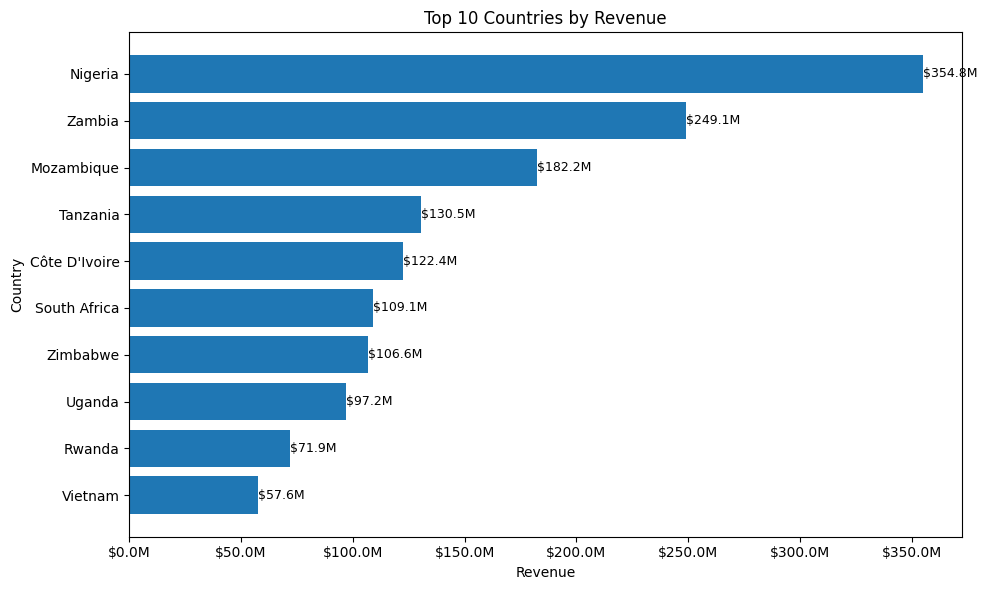

In [12]:
fig = plot_top_countries_by_revenue(df_clean, top_n=10)
plt.show()


Summary by country:
         Country  Line Item Quantity  Line Item Value
0    Afghanistan               115.0     4.617350e+03
1         Angola              3920.0     1.984000e+05
2         Belize               300.0     6.300000e+02
3          Benin            137349.0     7.877255e+05
4       Botswana            119532.0     1.632899e+06
5   Burkina Faso               165.0     4.512500e+02
6        Burundi            203212.0     3.351580e+06
7       Cameroon           1822831.0     1.477995e+07
8     Congo, Drc            520546.0     5.792916e+06
9  Côte D'Ivoire          12138186.0     1.223888e+08

Shipments count by country:
         Country  Total Shipments
0    Afghanistan                3
1         Angola                7
2         Belize                1
3          Benin               13
4       Botswana               70
5   Burkina Faso                2
6        Burundi               98
7       Cameroon               76
8     Congo, Drc              334
9  Côte D'Ivoire

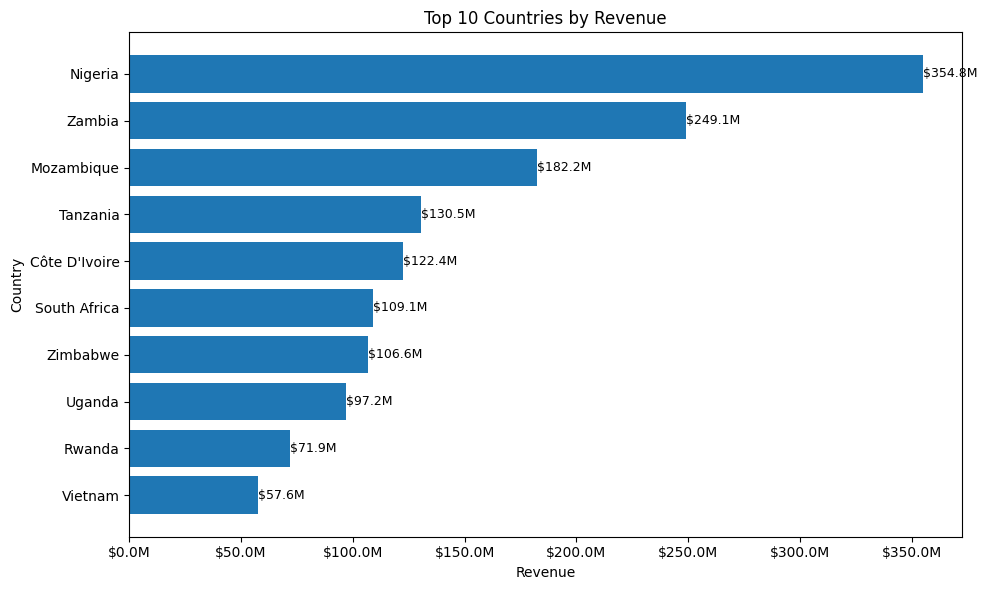

In [13]:
run_country_analysis(df_clean)